---
title: Hidden Markov Model with Control (Part 1)
subtitle: Control a Roomba using Active Inference and RxInfer
author: Kobus Esterhuysen
date: '2024-05-10'
date-modified: last-modified
categories:
  - Bayesian Inference
  - Active Inference
  - RxInfer
  - Julia
image: HMMwithControl.png
format:
  html:
    toc: true
    toc-depth: 4
    toc-expand: true
    toc-title: TOC
    code-fold: false
---

In [ ]:
#| hide
# BASED ON
  # HMMwithControl_PORT^v5.ipynb
  # HMMwithControl_PORT^v4.ipynb
  # HMMwithControl_PORT^v3.ipynb
  # HMMwithControl_PORT^v2.ipynb
  # HMMwithControl_PORT^v1.ipynb
  # Hidden Markov Model_ANNO^v5.ipynb
    
# DONE
# v2 starts ------------------------------------------------
# Upgrade to latest Julia (1.10.4)
# Upgrade to latest RxInfer (3.6.0)
# v3 starts ------------------------------------------------
# DeVries --> Namjoshi
# change x --> o (for observation)
# tildes --> * for true quantities
# remove all underscores indicating globals
# add underscores for bold symbols which have spatial structure
# add ː (\lmrk) for time-sequences
# migrate to cursor & github
# WRONG !!! The 1-hotness does not count as a spatial structure
#     it HAS to have spatial structure coz gets multiplied by a matrix
#     similar to $\hat{y}$ with continuous Dirac-delta sample
#     everything is 1-hot for signals in discrete AIF
#     everything is BOLD in discrete AIF
#         components (state factors or observation modalities) of vectors will be \boldsymbol
#         matrices for factors/modalities will be \boldsymbol
#         compound vectors (state vector or observation vector) will be \mathbf
#         compound matrices (factors/modalities) will be \mathbf
# _oᴿᵒᵒᵐ --> _oᵀᵉˣᵗᵘʳᵉ
# clean for publication
# v4 starts ------------------------------------------------
# v5 starts ------------------------------------------------
# have hats for sampled vars, i.e. realizations
# more Namjoshi symbols
# tuple0() for 0-based indexing to fit Namjoshi's math (also same as python)
# have tuple symbology
# v6  starts ------------------------------------------------
# clean for publication

# TODO
# latest RxInfer
# latest Plots



# Hidden Markov Model with Control (Part 1)

## 1 BUSINESS UNDERSTANDING

This is the first part of an effort to add control to the *Hidden Markov Model* RxInfer example. Eventually this work will be used in a more elaborate scheduling project making use of active inference.

In this part, we will simply be tracking a Roomba as it moves throughout a 3-room apartment consisting of a bedroom, a living room, and a bathroom. In addition, we start to wrap the original functionality with the usual structure:

- `create_envir()`
    - `execute()`
    - `observe()`
    - `state()` (true state, for evaluation only)
- `create_agent()`
    - `act()` [not yet]
    - `future()` [not yet]
    - `compute()`
    - `slide()` [not yet]

In the `compute()` function, which takes care of inference, the agent infers the Roomba's room at each time step and learns its matrices $\boldsymbol{A}^{[0]}$ and $\boldsymbol{B}^{[0]}$. We also swapped the roles of these matrices compared to the original RxInfer example, which follows the engineering convention of using $A$ for state transitions. Here, as in the active inference literature, $\boldsymbol{A}$ is the observation (likelihood) matrix and $\boldsymbol{B}$ the state transition matrix.

In [1]:
versioninfo() ## Julia version

Julia Version 1.11.6
Commit 9615af0f269 (2025-07-09 12:58 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 12 × Intel(R) Core(TM) i7-8700B CPU @ 3.20GHz
  WORD_SIZE: 64
  LLVM: libLLVM-16.0.6 (ORCJIT, skylake)
Threads: 1 default, 0 interactive, 1 GC (on 12 virtual cores)


In [2]:
import Pkg
# Pkg.add(Pkg.PackageSpec(;name="RxInfer", version="3.6.0"))
Pkg.add(Pkg.PackageSpec(;name="RxInfer"))
Pkg.add(Pkg.PackageSpec(;name="Random"))
# Pkg.add(Pkg.PackageSpec(;name="Plots", version="1.40.1"))
Pkg.add(Pkg.PackageSpec(;name="Plots"))
Pkg.add(Pkg.PackageSpec(;name="XLSX"))
Pkg.add(Pkg.PackageSpec(;name="DataFrames"))
Pkg.add(Pkg.PackageSpec(;name="BenchmarkTools"))
Pkg.add(Pkg.PackageSpec(;name="Distributions"))
Pkg.add(Pkg.PackageSpec(;name="OffsetArrays"))

using RxInfer, Random, BenchmarkTools, Distributions, Plots, XLSX, DataFrames, OffsetArrays

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.to

In [3]:
Pkg.status()

Status `~/.julia/environments/v1.11/Project.toml`
  [6e4b80f9] BenchmarkTools v1.8.0
  [a93c6f00] DataFrames v1.8.2
  [31c24e10] Distributions v0.25.131
  [6fe1bfb0] OffsetArrays v1.17.0
⌃ [91a5bcdd] Plots v1.40.1
⌃ [86711068] RxInfer v3.6.0
⌃ [fdbf4ff8] XLSX v0.12.3
  [9a3f8284] Random v1.11.0
Info Packages marked with ⌃ have new versions available and may be upgradable.


In [4]:
## tuple0(x...): build a 0-based tuple (x^{[0]}, ..., x^{[N]}), mirroring the math.
##   - each argument becomes one entry: tuple0(v) wraps v; it never re-indexes v itself
##   - the index range 0:N is derived from the number of arguments
##   - entries may differ in shape, e.g. likelihood matrices for different modalities
## Returns an OffsetVector (mutable), not a Julia Tuple.
tuple0(x...) = OffsetVector(collect(x), 0:length(x)-1)

tuple0 (generic function with 1 method)

**Why `tuple0()` rather than `OffsetVector()` directly?**

1. **It prevents a level mix-up.** With `OffsetVector`, it is easy to offset the *wrong level*:

```julia
    OffsetVector([1.0, 0.0, 0.0], 0:2)    ## the one-hot vector itself, re-indexed 0:2 (wrong level)
    OffsetVector([[1.0, 0.0, 0.0]], 0:0)  ## a tuple containing the one-hot vector (intended)
    tuple0([1.0, 0.0, 0.0])               ## the same as the second line, with no way to get it wrong
```

    The first line is valid code but means something else: the one-hot vector $\hat{\boldsymbol{s}}^{\ast[0,0]}$ itself, now indexed from 0, rather than the tuple $\hat{\mathbf{s}}^{\ast(0)} = \big(\hat{\boldsymbol{s}}^{\ast[0,0]}\big)$. Nothing would complain, and later code that indexes `[0]` would get a single number instead of a vector. `tuple0` always wraps its arguments as *entries*, so this mistake cannot happen.

2. **The index range is computed automatically.** With `OffsetVector`, the range is written by hand and has to agree with the number of entries: adding a second modality to `LAˣ` while forgetting to change `0:0` to `0:1` gives an error at best. `tuple0` derives the range from the number of arguments, so adding or removing an entry is a one-line change.

3. **It reads like the math.** `tuple0(A0, A1)` looks like $\big(\boldsymbol{A}^{[0]}, \boldsymbol{A}^{[1]}\big)$: entries separated by commas, nothing else. `OffsetVector([A0, A1], 0:1)` adds square brackets and a range that have nothing to do with the math.

4. **It states the intent.** `OffsetVector` says "an array with shifted indices", which could be anything. `tuple0` says "a tuple of factors or modalities, as in the math", the specific concept from (10.33). And since all tuples are built the same way, a search for `tuple0(` finds every one of them.

5. **There is one place to change things.** Changing how tuples work, e.g. switching to an immutable 0-based type, or adding a check that every column of every $\boldsymbol{A}$ and $\boldsymbol{B}$ sums to 1, means changing one line instead of every place a tuple is built.

6. **Entries of different shapes just work.** `collect` builds a vector of whatever is passed in, so `tuple0(A0, A1)` with a $3\times 3$ and a $2\times 3$ matrix gives a vector of matrices, which is exactly what a tuple of likelihood matrices with different numbers of observations needs.

## 2 DATA UNDERSTANDING

The data will consist of a time-series of 1-hot encoded position states. When the associated component of the state vector is a 1, the Roomba will be present in the associated room.

## 3 DATA PREPARATION

We will use the data from the simulation directly. There is no need to perform additional data preparation.

## 4 MODELING

### 4.1 Narrative

In general, we will have the following symbol conventions. They are shown for states $s$; observations $o$ follow the same pattern.

**Indices.** Time-only indices are written in $(\,)$, compound or non-time indices in $[\,]$. The index therefore tells you what kind of object you are looking at: a superscript $(t)$ collects everything at time $t$, while $[t,n]$ picks out a single state factor $n$ at time $t$.

- $t$: time step, $t = 0, \ldots, T$
- $s^{[t,n]}$: categorical random variable for state factor $n$ at time $t$. Its values are labels, e.g. $\{\text{bedroom}, \text{livingroom}, \text{bathroom}\}$. It is not bold, because a single categorical random variable has no structure.
- $\mathbf{s}^{(t)} = \big(s^{[t,0]}, \ldots, s^{[t,N]}\big)$: tuple of the random variables of all state factors at time $t$

**Fonts.** Bold marks anything with structure, and the style of bold tells you which kind:

- upright bold ($\mathbf{s}$, $\mathbf{A}$): a *tuple*, an ordered collection whose entries may differ in size, such as one entry per state factor or observation modality
- italic bold ($\boldsymbol{s}$, $\boldsymbol{A}$): a single *vector* or *matrix*, such as a one-hot vector, a probability vector, a belief, or a likelihood matrix

For example, $\mathbf{A} = \big(\boldsymbol{A}^{[0]}, \ldots, \boldsymbol{A}^{[M]}\big)$ is the tuple of likelihood matrices, and $\boldsymbol{A}^{[m]}$ is the matrix for observation modality $m$. Likewise, $\mathbf{B} = \big(\boldsymbol{B}^{[0]}, \ldots, \boldsymbol{B}^{[N]}\big)$ and $\mathbf{D} = \big(\boldsymbol{D}^{[0]}, \ldots, \boldsymbol{D}^{[N]}\big)$ collect one array per state factor. Upright bold is only used for Latin letters, because Greek letters such as $\pi$ do not render in upright bold.

**Marks.** A hat marks a *realized* value: something that has actually happened. A bold symbol without a hat is a *distribution*: a probability vector over possible values.

- $\hat{\boldsymbol{s}}^{[t,n]}$: realized value of $s^{[t,n]}$, one-hot encoded as a vector, e.g. $[1,0,0]^{\top}$
- $\hat{\mathbf{s}}^{(t)} = \big(\hat{\boldsymbol{s}}^{[t,0]}, \ldots, \hat{\boldsymbol{s}}^{[t,N]}\big)$: tuple of the realized values of all state factors at time $t$
- $\hat{\mathbf{s}}^{(0:T)} = \big(\hat{\mathbf{s}}^{(0)}, \ldots, \hat{\mathbf{s}}^{(T)}\big)$: trajectory (sequence over time) of realized states
- $\boldsymbol{s}^{[t,n]}$, without a hat: the agent's *belief* about state factor $n$ at time $t$, a probability vector with one entry per value of $s^{[t,n]}$
- $\boldsymbol{B}^{\ast[0]}\,\hat{\boldsymbol{s}}^{\ast[t-1,0]}$: a probability vector (here, over the next state), not a realized value

The agent never observes the states, so its state variables never carry a hat: it has random variables $s^{[t,n]}$ and beliefs $\boldsymbol{s}^{[t,n]}$. The observations are different, because the agent does receive them. Each observation therefore appears in three forms, which share the same index but are different objects:

- $o^{[t,0]}$: the categorical random variable for the Texture observation at time $t$, with values $\{\text{hardwood}, \text{carpet}, \text{tiles}\}$
- $\hat{\boldsymbol{o}}^{[t,0]}$: the observation the agent actually *received*, one-hot encoded. If the camera reads hardwood at time $t$, then $\hat{\boldsymbol{o}}^{[t,0]} = [1,0,0]^{\top}$, and the tuple of all modalities is $\hat{\mathbf{o}}^{(t)} = \big([1,0,0]^{\top}\big)$.
- $\boldsymbol{o}^{[t,0]}$, without a hat: an *expected* observation, i.e. a probability vector the agent computes from its beliefs, $\boldsymbol{o}^{[t,0]} = \boldsymbol{A}^{[0]}\,\boldsymbol{s}^{[t,0]}$

For example, suppose the agent believes the Roomba is most likely in the bedroom, $\boldsymbol{s}^{[t,0]} = [0.7, 0.2, 0.1]^{\top}$, and its likelihood matrix $\boldsymbol{A}^{[0]}$ has the same values as $\boldsymbol{A}^{\ast[0]}$. Then it expects

$$
\boldsymbol{o}^{[t,0]} = \boldsymbol{A}^{[0]}\,\boldsymbol{s}^{[t,0]} =
\begin{bmatrix} 0.9 & 0.05 & 0.05 \\ 0.05 & 0.9 & 0.05 \\ 0.05 & 0.05 & 0.9 \end{bmatrix}
\begin{bmatrix} 0.7 \\ 0.2 \\ 0.1 \end{bmatrix}
=
\begin{bmatrix} 0.645 \\ 0.22 \\ 0.135 \end{bmatrix}
$$

that is, hardwood with probability 0.645, carpet 0.22, and tiles 0.135. If the camera then reads carpet, the received observation is $\hat{\boldsymbol{o}}^{[t,0]} = [0,1,0]^{\top}$: a single definite outcome, which the agent uses to update its belief $\boldsymbol{s}^{[t,0]}$ toward the living room.

So, for observations the agent has both hatted and unhatted forms: what it expects ($\boldsymbol{o}$) and what it gets ($\hat{\boldsymbol{o}}$). For states, it only ever has the unhatted forms: the random variable $s^{[t,n]}$ and the belief $\boldsymbol{s}^{[t,n]}$. Only the environment has $\hat{\boldsymbol{s}}^{\ast[t,n]}$, the room the Roomba is really in.

**The asterisk** ${}^{\ast}$ marks what belongs to the environment (the generative process), e.g. $\hat{\mathbf{s}}^{\ast(t)}$ and $\boldsymbol{B}^{\ast[0]}$. Symbols without it belong to the agent (the generative model), e.g. its own matrices $\boldsymbol{A}^{[m]}$ and $\boldsymbol{B}^{[n]}$, which it learns so that they approximate $\boldsymbol{A}^{\ast[m]}$ and $\boldsymbol{B}^{\ast[n]}$. The observation $\hat{\mathbf{o}}^{(t)}$ has no asterisk because it is shared: the environment generates it and the agent receives it.

**Code symbols.** The code mirrors the math as closely as identifiers allow:

- `L` prefix: upright bold ($\mathbf{s}$, $\mathbf{A}$), a tuple. The `L` suggests verticality (upright).
- `_` prefix: italic bold ($\boldsymbol{s}$, $\boldsymbol{A}$), a single vector or matrix that is not part of a tuple. The `_` suggests the underline of bold.
- hat: a Unicode circumflex on the letter, e.g. `ŝ` for $\hat{s}$, `ô` for $\hat{o}$
- asterisk ${}^{\ast}$: a superscript `ˣ` (typed `\^x` then Tab)
- time index $(t)$: a subscript in the name: `ₜ` for $t$, `ₜ₋₁` for $t-1$, `₀` for $t=0$
- trajectory $(0{:}T)$: a `ː` suffix (triangular colon), e.g. `Lôː` for $\hat{\mathbf{o}}^{(0:T)}$
- tuple index $[n]$ or $[m]$: real 0-based indexing, e.g. `LAˣ[0]`. In Julia, tuples are built with `tuple0(...)` (an `OffsetVector` indexed from 0). In Python, ordinary tuples and lists are already 0-based.

**Indexing and the tear-off mnemonic.** Only tuples have names; their entries are written by indexing. Read a factor or modality index (`[n]` or `[m]`) as tearing the vertical line off the `L`, turning it into `_`: `LAˣ[0]` reads as `_Aˣ[0]`, i.e. italic bold $\boldsymbol{A}^{\ast[0]}$, just as indexing into a tuple turns the upright $\mathbf{A}^{\ast}$ into the italic $\boldsymbol{A}^{\ast[0]}$ in the math. Three details:

- A time index into a trajectory does *not* tear off the line: `Lŝˣː[t]` is still a tuple, $\hat{\mathbf{s}}^{\ast(t)}$. Only the factor index that follows tears it off: `Lŝˣː[t][0]` is $\hat{\boldsymbol{s}}^{\ast[t,0]}$.
- The mnemonic applies wherever the brackets appear, on either side of an assignment: `LAˣ[0] = …` assigns to $\boldsymbol{A}^{\ast[0]}$.
- Each further index changes the font of the result as it would in the math: `LAˣ[0][1,2]` is a single number, an entry of the matrix $\boldsymbol{A}^{\ast[0]}$, so it is no longer bold at all.

Since each tuple has exactly one name, there is nothing to keep in sync: when a tuple gets a new value, a single assignment updates it, e.g. `Lŝˣₜ = tuple0(...)`.

| Math | Code | Meaning |
|---|---|---|
| $\mathbf{A}^{\ast}$, $\mathbf{B}^{\ast}$, $\mathbf{D}^{\ast}$ | `LAˣ`, `LBˣ`, `LDˣ` | environment's tuples of arrays |
| $\boldsymbol{A}^{\ast[0]}$, $\boldsymbol{B}^{\ast[0]}$, $\boldsymbol{D}^{\ast[0]}$ | `LAˣ[0]`, `LBˣ[0]`, `LDˣ[0]` | environment's arrays for modality / factor 0 |
| $\mathbf{A}$, $\mathbf{B}$, $\mathbf{D}$ | `LA`, `LB`, `LD` | agent's tuples of arrays |
| $\boldsymbol{A}^{[0]}$, $\boldsymbol{B}^{[0]}$, $\boldsymbol{D}^{[0]}$ | `LA[0]`, `LB[0]`, `LD[0]` | agent's arrays for modality / factor 0 |
| $\hat{\mathbf{s}}^{\ast(0)}$ | `Lŝˣ₀` | true initial state tuple |
| $\hat{\mathbf{s}}^{\ast(t)}$, $\hat{\mathbf{s}}^{\ast(t-1)}$ | `Lŝˣₜ`, `Lŝˣₜ₋₁` | true state tuple at $t$, $t-1$ |
| $\hat{\boldsymbol{s}}^{\ast[t,0]}$ | `Lŝˣₜ[0]` | true Room state at $t$ (one-hot) |
| $\hat{\mathbf{s}}^{\ast(0:T)}$ | `Lŝˣː` | trajectory of true states |
| $\hat{\mathbf{s}}^{\ast(t)}$, $\hat{\boldsymbol{s}}^{\ast[t,0]}$ (from the trajectory) | `Lŝˣː[t]`, `Lŝˣː[t][0]` | entry $t$ of the trajectory, and its Room factor |
| $\hat{\mathbf{o}}^{(t)}$ | `Lôₜ` | received observation tuple at $t$ |
| $\hat{\boldsymbol{o}}^{[t,0]}$ | `Lôₜ[0]` | received Texture observation at $t$ (one-hot) |
| $\hat{\mathbf{o}}^{(0:T)}$ | `Lôː` | trajectory of received observations |
| $\boldsymbol{B}^{\ast[0]}\,\hat{\boldsymbol{s}}^{\ast[t-1,0]}$ | `LBˣ[0] * Lŝˣₜ₋₁[0]` | probability vector over the next room |
| $\boldsymbol{s}^{[t,n]}$ | `Lsₜ[n]` | agent's belief about factor $n$ at $t$ (probability vector) |
| $t$, $T$ | `t`, `T` | time step, last time step |

The code stores the agent's *beliefs*, not its random variables. So the tuple `Lsₜ` holds the beliefs $\big(\boldsymbol{s}^{[t,0]}, \ldots, \boldsymbol{s}^{[t,N]}\big)$, while in the math, $\mathbf{s}^{(t)}$ denotes the tuple of random variables.

In Python, `ˣ` is normalized to a plain `x`, so `LAˣ` and `LAx` are the same name; never use `LAx` for anything else.

### 4.2 Core Elements

This section attempts to answer three important questions:

- What metrics are we going to track?
- What decisions do we intend to make?
- What are the sources of uncertainty?

The only metric we are interested in is the position of the Roomba, i.e. in which of the 3 rooms it finds itself at each time step.

There are no control/steering decisions to be made (yet). We are simply interested in tracking the behavior of the Roomba.

There are two sources of uncertainty in the environment itself. The first has to do with the fact that the state transitions are not deterministic but rather stochastic. This is captured in the tuple of state transition matrices $\mathbf{B}^{\ast}$. State transitions for each *state factor* are captured in a matrix $\boldsymbol{B}^{\ast[n]}$, where $n$ is the index of the state factor.

The second relates to observations. The Roomba's camera sometimes misidentifies the floor surface in a room. This uncertainty is captured in the tuple of observation generation matrices $\mathbf{A}^{\ast}$. Observation generation for each *observation modality* is captured in a matrix $\boldsymbol{A}^{\ast[m]}$, where $m$ is the index of the observation modality.

The initial state is not a source of uncertainty in the environment, because the Roomba always starts in the bedroom.

Finally, there is a third source of uncertainty, on the agent's side: the agent does not know $\mathbf{A}^{\ast}$ and $\mathbf{B}^{\ast}$. It has to learn its own tuples of matrices $\mathbf{A}$ and $\mathbf{B}$ from the observations, and this uncertainty decreases as it observes more data. The agent also does not know the starting room, so it begins with a uniform prior over the three rooms.

### 4.3 System-Under-Steer / Environment / Generative Process

First, before tracking the Roomba's movements using `RxInfer`, we describe the environment it moves in, i.e. the *generative process* that produces the data. Since we have a discrete set of rooms in the apartment, we can use a categorical distribution to represent the Roomba's position. There are three rooms in the apartment, meaning we need three states in our categorical distribution. At time $t$, the Roomba's true position is the realized state tuple
$$
\hat{\mathbf{s}}^{\ast(t)} = \big(\hat{\boldsymbol{s}}^{\ast[t,0]}\big)
$$
whose entry $\hat{\boldsymbol{s}}^{\ast[t,0]}$ is the one-hot encoded value of a single *state factor*, factor 0 (Room), with possible values

- $s^{\ast[t,0]} \in \{\text{bedroom}, \text{livingroom}, \text{bathroom}\}$

The Roomba's starting room is given by the initial state distribution $\mathbf{D}^{\ast} = (\boldsymbol{D}^{\ast[0]})$. In our simulation, the Roomba always starts in the bedroom, so $\boldsymbol{D}^{\ast[0]} = [1,0,0]^{\top}$. Some rooms are more accessible than others, meaning the Roomba is more likely to move between these rooms - for example, there is no door directly between the bedroom and the living room, so the Roomba has to pass through the bathroom. The true transition probabilities are captured by $\mathbf{B}^{\ast} = (\boldsymbol{B}^{\ast[0]})$, with transition matrix $\boldsymbol{B}^{\ast[0]} \in [0,1]^{3\times 3}$ for this single state factor.

Our Roomba is equipped with a small camera that tracks the surface it is moving over. This camera provides the observations, since there are

- hardwood floors in the bedroom
- carpet in the living room, and
- tiles in the bathroom.

However, this method is not foolproof, and sometimes the Roomba will mistake one floor type for another. Don't be too hard on the little guy, it's just a Roomba after all.

At time $t$, the received observation tuple is $\hat{\mathbf{o}}^{(t)} = \big(\hat{\boldsymbol{o}}^{[t,0]}\big)$, whose entry $\hat{\boldsymbol{o}}^{[t,0]}$ is the one-hot encoded value of a single *observation modality*, modality 0 (Texture), with possible values

- $o^{[t,0]} \in \{\text{hardwood}, \text{carpet}, \text{tiles}\}$

The true mapping from the Roomba's position to the observations is $\mathbf{A}^{\ast} = (\boldsymbol{A}^{\ast[0]})$, with likelihood matrix $\boldsymbol{A}^{\ast[0]} \in [0,1]^{3\times 3}$ for this single observation modality. $\boldsymbol{A}^{\ast[0]}$ also encodes the probability that the Roomba will make a mistake and get the wrong observation. This leaves us with the following generative process specification:

$$
\mathcal{E} \;\triangleq\;
\begin{cases}
\hat{\boldsymbol{s}}^{\ast[0,0]} \sim \mathcal{Cat}\big(\boldsymbol{D}^{\ast[0]}\big) & \text{INITIAL STATE}\\[2pt]
\hat{\boldsymbol{s}}^{\ast[t,0]} \sim \mathcal{Cat}\big(\boldsymbol{B}^{\ast[0]}\,\hat{\boldsymbol{s}}^{\ast[t-1,0]}\big), \quad t>0 & \text{STATE TRANSITION}\\[2pt]
\hat{\boldsymbol{o}}^{[t,0]} \sim \mathcal{Cat}\big(\boldsymbol{A}^{\ast[0]}\,\hat{\boldsymbol{s}}^{\ast[t,0]}\big) & \text{OBSERVATION GENERATION}
\end{cases}
$$

Because $\hat{\boldsymbol{s}}^{\ast[t-1,0]}$ and $\hat{\boldsymbol{s}}^{\ast[t,0]}$ are one-hot, the products $\boldsymbol{B}^{\ast[0]}\,\hat{\boldsymbol{s}}^{\ast[t-1,0]}$ and $\boldsymbol{A}^{\ast[0]}\,\hat{\boldsymbol{s}}^{\ast[t,0]}$ simply pick out the column for the current room: a probability vector over next rooms and over textures, respectively.

This process has the structure of a *Hidden Markov Model* or HMM for short: the room is a hidden Markov chain, and the camera emits noisy observations of it. The agent never sees $\boldsymbol{A}^{\ast[0]}$ or $\boldsymbol{B}^{\ast[0]}$ directly. Its goal is to learn its own matrices $\boldsymbol{A}^{[0]}$ and $\boldsymbol{B}^{[0]}$ from the observations, so that they approximate the true ones and it can track the whereabouts of our little cleaning agent.

In [5]:
Lŝˣ₀ = tuple0([1.0, 0.0, 0.0])    ## ŝ^{*(0)} = (ŝ^{*[0,0]}): initial state, Roomba starts in the bedroom

1-element OffsetArray(::Vector{Vector{Float64}}, 0:0) with eltype Vector{Float64} with indices 0:0:
 [1.0, 0.0, 0.0]

#### 4.3.1 State and Observation variables

The *state variables* represent *what we need to know*. The true state of the Roomba at time $t$ is given by a (compound) tuple $\hat{\mathbf{s}}^{\ast(t)}$ whose components are the one-hot encoded state factors (here a single factor):

$$
\hat{\mathbf{s}}^{\ast(t)} = \big(\hat{\boldsymbol{s}}^{\ast[t,0]}\big)
$$

where the *state factors* are:

- factor 0 (Room):
    - $s^{\ast[t,0]} \in \{\text{bedroom}, \text{livingroom}, \text{bathroom}\}$,
    - one-hot encoded as $\hat{\boldsymbol{s}}^{\ast[t,0]} \in \big\{[1,0,0]^{\top}, [0,1,0]^{\top}, [0,0,1]^{\top}\big\}$

The *observation variables* represent *what we can sense*. Similarly, the (compound) observation tuple received by the Roomba at time $t$ is given by

$$
\hat{\mathbf{o}}^{(t)} = \big(\hat{\boldsymbol{o}}^{[t,0]}\big)
$$

where the *observation modalities* are:

- modality 0 (Texture):
    - $o^{[t,0]} \in \{\text{hardwood}, \text{carpet}, \text{tiles}\}$,
    - one-hot encoded as $\hat{\boldsymbol{o}}^{[t,0]} \in \big\{[1,0,0]^{\top}, [0,1,0]^{\top}, [0,0,1]^{\top}\big\}$

#### 4.3.2 Decision variables

There are no decisions to be made (yet). We are simply observing the behavior of the Roomba, i.e. there is no control/steering applied to the environment.

#### 4.3.3 Exogenous forces

There are no exogenous force variables (yet). We may add some in followup parts, for example, having certain doors closed at random.

#### 4.3.4 State Transition and Observation Generation functions

Starting from $\hat{\boldsymbol{s}}^{\ast[0,0]} \sim \mathcal{Cat}\big(\boldsymbol{D}^{\ast[0]}\big)$, with $\boldsymbol{D}^{\ast[0]} = [1,0,0]^{\top}$ (the bedroom), the environment evolves according to

$$
\begin{aligned}
\hat{\boldsymbol{s}}^{\ast[t,0]} &\sim \mathcal{Cat}\big(\boldsymbol{B}^{\ast[0]}\,\hat{\boldsymbol{s}}^{\ast[t-1,0]}\big), \quad t>0 && \text{STATE TRANSITION}\\
\hat{\boldsymbol{o}}^{[t,0]} &\sim \mathcal{Cat}\big(\boldsymbol{A}^{\ast[0]}\,\hat{\boldsymbol{s}}^{\ast[t,0]}\big) && \text{OBSERVATION GENERATION}
\end{aligned}
$$

##### State Transition model $\boldsymbol{B}^{\ast[0]}$ (factor 0, Room)

Each column is a probability distribution over the next room, given the previous room, so each column sums to 1.

| next room $s^{\ast[t,0]}$ \ previous room $s^{\ast[t-1,0]}$ | bedroom | livingroom | bathroom |
| --- | --- | --- | --- |
| **bedroom**    | 0.9 | 0.0 | 0.1 |
| **livingroom** | 0.0 | 0.9 | 0.1 |
| **bathroom**   | 0.1 | 0.1 | 0.8 |

The zeros mean there is no door between the bedroom and the living room: the Roomba has to pass through the bathroom.

##### Observation Generation model $\boldsymbol{A}^{\ast[0]}$ (modality 0, Texture)

Each column is a probability distribution over the observed texture, given the room the Roomba is in, so each column sums to 1.

| observation $o^{[t,0]}$ \ room $s^{\ast[t,0]}$ | bedroom | livingroom | bathroom |
| --- | --- | --- | --- |
| **hardwood** | 0.9  | 0.05 | 0.05 |
| **carpet**   | 0.05 | 0.9  | 0.05 |
| **tiles**    | 0.05 | 0.05 | 0.9  |

The off-diagonal entries are the camera's mistakes: in each room, it misreads the floor with probability 0.1, split equally between the two other textures.

In [6]:
LBˣ = tuple0(
    [0.9  0.0  0.1;    ## rows: next room (bedroom, livingroom, bathroom)
     0.0  0.9  0.1;    ## columns: previous room (bedroom, livingroom, bathroom)
     0.1  0.1  0.8],
)
LBˣ[0]    ## the Room transition matrix, B^{*[0]}

3×3 Matrix{Float64}:
 0.9  0.0  0.1
 0.0  0.9  0.1
 0.1  0.1  0.8

##### Observation Generation model $\boldsymbol{A}^{\ast[0]}$ (modality 0, Texture)

Each column is a probability distribution over the observed texture, given the room the Roomba is in, so each column sums to 1.

| observation $o^{[t,0]}$ \ room $s^{\ast[t,0]}$ | bedroom | livingroom | bathroom |
| --- | --- | --- | --- |
| **hardwood** | 0.9  | 0.05 | 0.05 |
| **carpet**   | 0.05 | 0.9  | 0.05 |
| **tiles**    | 0.05 | 0.05 | 0.9  |

The off-diagonal entries are the camera's mistakes: in each room, it misreads the floor with probability 0.1, split equally between the two other textures.

In [7]:
LAˣ = tuple0(
    [0.9  0.05 0.05;    ## rows: hardwood, carpet, tiles
     0.05 0.9  0.05;    ## columns: bedroom, livingroom, bathroom
     0.05 0.05 0.9],
)
LAˣ[0]    ## the Texture likelihood matrix, A^{*[0]}

3×3 Matrix{Float64}:
 0.9   0.05  0.05
 0.05  0.9   0.05
 0.05  0.05  0.9

#### 4.3.5 Objective function

The objective function is such that the Bethe free energy (BFE) or Generalized free energy (GFE) is minimized. This aspect will be handled by the `RxInfer` Julia package.

#### 4.3.6 Implementation of the System-Under-Steer / Environment / Generative Process

In [8]:
## returns a one-hot encoding of a random sample from a categorical distribution
function rand_1hot_vec(rng, distribution::Categorical)
    K = ncategories(distribution)
    sample = zeros(K)
    drawn_category = rand(rng, distribution)
    sample[drawn_category] = 1.0
    return sample
end

rand_1hot_vec (generic function with 1 method)

In [9]:
function create_envir(; LAˣ, LBˣ, Lŝˣ₀, seed=42)
    rng = MersenneTwister(seed)

    ## t = 0
    Lŝˣₜ = Lŝˣ₀                                              ## ŝ^{*(0)}
    Loₜ  = tuple0(LAˣ[0] * Lŝˣₜ[0])                          ## A^{*[0]} ŝ^{*[0,0]}
    Lôₜ  = tuple0(rand_1hot_vec(rng, Categorical(Loₜ[0])))   ## ô^{[0,0]} ~ Cat(...)

    execute = () -> begin
        Lŝˣₜ₋₁ = Lŝˣₜ
        Lsˣₜ = tuple0(LBˣ[0] * Lŝˣₜ₋₁[0])                         ## B^{*[0]} ŝ^{*[t-1,0]}
        Lŝˣₜ = tuple0(rand_1hot_vec(rng, Categorical(Lsˣₜ[0])))   ## ŝ^{*[t,0]} ~ Cat(...)
        Loₜ  = tuple0(LAˣ[0] * Lŝˣₜ[0])                          ## A^{*[0]} ŝ^{*[t,0]}
        Lôₜ  = tuple0(rand_1hot_vec(rng, Categorical(Loₜ[0])))   ## ô^{[t,0]} ~ Cat(...)
        nothing
    end

    observe = () -> Lôₜ     ## ô^{(t)}
    state   = () -> Lŝˣₜ    ## ŝ^{*(t)}, true state (for evaluation only)

    return (execute, observe, state)
end

create_envir (generic function with 1 method)

In order to generate data to mimic the observations of the Roomba, we need to specify three things: the initial state (i.e., in which room the Roomba starts), the actual transition probabilities between the states $\boldsymbol{B}^{\ast[0]}$ (i.e., how likely the Roomba is to move from one room to another), and the observation distribution $\boldsymbol{A}^{\ast[0]}$ (i.e., what type of texture the Roomba will observe in each room). We can then use these specifications to generate observations from the generative process, which has the structure of a hidden Markov model (HMM).

To generate our observation data, we'll follow these steps:
1. Assume an initial state for the Roomba, $\hat{\boldsymbol{s}}^{\ast[0,0]}$. For example, we can start the Roomba in the bedroom.
2. Determine the observation in the starting room by drawing from the categorical distribution $\boldsymbol{A}^{\ast[0]}\,\hat{\boldsymbol{s}}^{\ast[0,0]}$, i.e. the column of $\boldsymbol{A}^{\ast[0]}$ for that room.
3. Determine where the Roomba goes next by drawing from the categorical distribution $\boldsymbol{B}^{\ast[0]}\,\hat{\boldsymbol{s}}^{\ast[t-1,0]}$, i.e. the column of $\boldsymbol{B}^{\ast[0]}$ for the current room.
4. Determine the observation in the new room by drawing from $\boldsymbol{A}^{\ast[0]}\,\hat{\boldsymbol{s}}^{\ast[t,0]}$.
5. Repeat steps 3-4 for as many time steps as we want.

We will generate 600 data points ($t = 0, \ldots, T$ with $T = 599$) to simulate 600 ticks of the Roomba moving through the apartment. `Lôː` will contain the Roomba's observations of the floor it's on at each tick, $\hat{\mathbf{o}}^{(0:T)}$, and `Lŝˣː` will contain the room the Roomba was actually in, $\hat{\mathbf{s}}^{\ast(0:T)}$.

The following code implements this process and generates our observation data:

In [10]:
T = 599                           ## 600 ticks: t = 0, ..., T
Lŝˣ₀ = tuple0([1.0, 0.0, 0.0])    ## ŝ^{*(0)}: Roomba starts in the bedroom
(execute_sim, observe_sim, state_sim) = create_envir(; LAˣ=LAˣ, LBˣ=LBˣ, Lŝˣ₀=Lŝˣ₀)

Lŝˣː = OffsetVector(Vector{Any}(undef, T+1), 0:T)    ## ŝ^{*(0:T)}: true states
Lôː  = OffsetVector(Vector{Any}(undef, T+1), 0:T)    ## ô^{(0:T)}: observations
for t = 0:T
    t > 0 && execute_sim()     ## move and observe (t = 0 is already set up)
    Lŝˣː[t] = state_sim()
    Lôː[t]  = observe_sim()
end

In [11]:
[Lŝˣ[0] for Lŝˣ in Lŝˣː]    ## ŝ^{*[t,0]} for t = 0, ..., T: the Room factor

600-element OffsetArray(::Vector{Vector{Float64}}, 0:599) with eltype Vector{Float64} with indices 0:599:
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]

In [12]:
[Lô[0] for Lô in Lôː]    ## ô^{[t,0]} for t = 0, ..., T: the Texture modality

600-element OffsetArray(::Vector{Vector{Float64}}, 0:599) with eltype Vector{Float64} with indices 0:599:
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [1.0, 0.0, 0.0]

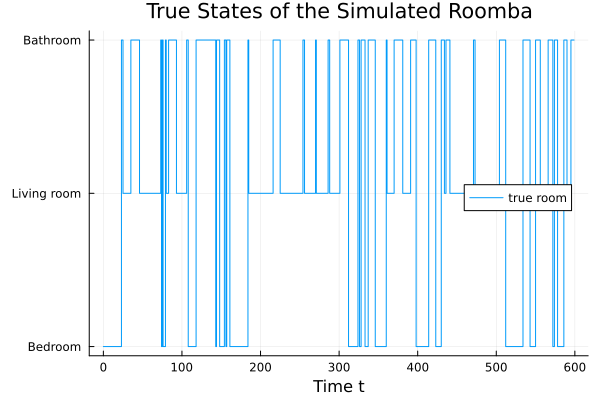

In [13]:
rooms = [argmax(Lŝˣ[0]) for Lŝˣ in parent(Lŝˣː)]    ## room index (1, 2, 3) of ŝ^{*[t,0]} for t = 0, ..., T
plot(title="True States of the Simulated Roomba")
plot!(
    0:T, rooms, linetype=:steppost, linestyle=:solid, leg=:right,
    label="true room", xlabel="Time t", yticks=(1:3, ["Bedroom", "Living room", "Bathroom"]))

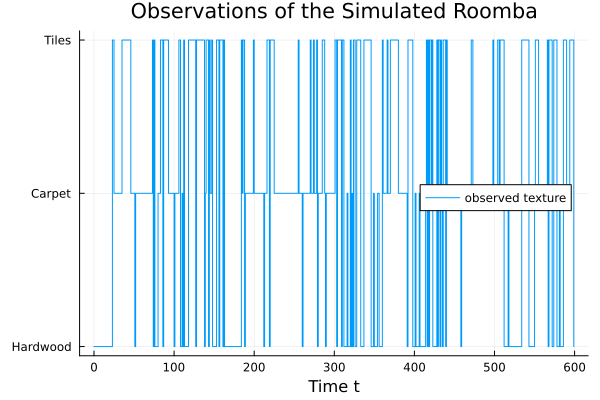

In [14]:
textures = [argmax(Lô[0]) for Lô in parent(Lôː)]    ## texture index (1, 2, 3) of ô^{[t,0]} for t = 0, ..., T
plot(title="Observations of the Simulated Roomba")
plot!(
    0:T, textures, linetype=:steppost, linestyle=:solid, leg=:right,
    label="observed texture", xlabel="Time t", yticks=(1:3, ["Hardwood", "Carpet", "Tiles"]))

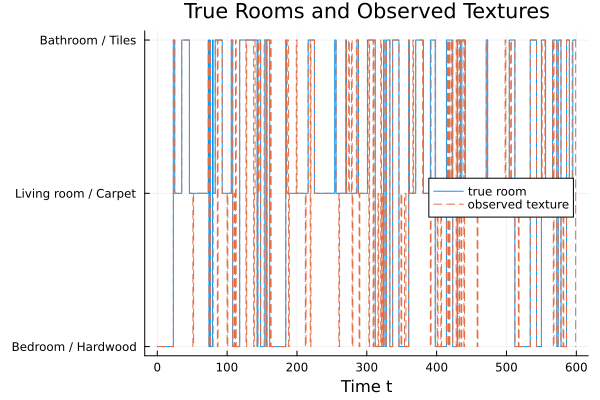

In [15]:
plot(title="True Rooms and Observed Textures")
plot!(0:T, rooms, linetype=:steppost, label="true room",
      yticks=(1:3, ["Bedroom / Hardwood", "Living room / Carpet", "Bathroom / Tiles"]))
plot!(0:T, textures, linetype=:steppost, linestyle=:dash, label="observed texture",
      xlabel="Time t", leg=:right)

In [16]:
mistakes = count(rooms .!= textures)
println("camera mistakes: $mistakes of $(T+1) ticks ($(round(100*mistakes/(T+1), digits=1))%)")

camera mistakes: 57 of 600 ticks (9.5%)


### 4.4 Uncertainty Model

The uncertainty in the environment is captured in the state transition matrix $\boldsymbol{B}^{\ast[0]}$ (factor 0, Room) and the observation generation matrix $\boldsymbol{A}^{\ast[0]}$ (modality 0, Texture). Their entries are the probabilities of the Roomba's moves and of the camera's readings. The initial state adds no uncertainty, because the Roomba always starts in the bedroom.

The agent's uncertainty about $\mathbf{A}^{\ast}$ and $\mathbf{B}^{\ast}$ themselves is not part of the environment. It is captured later, in the agent's model, by priors over its own tuples of matrices $\mathbf{A}$ and $\mathbf{B}$.

### 4.5 Agent / Generative Model

#### 4.5.1 State and Observation variables

On the agent's side, the state of the environment at time $t$ is not known: the agent represents it by a (compound) tuple of categorical random variables, one per state factor (here a single factor):

$$
\mathbf{s}^{(t)} = \big(s^{[t,0]}\big)
$$

where the *state factors* are:

- factor 0 (Room):
    - $s^{[t,0]} \in \{\text{bedroom}, \text{livingroom}, \text{bathroom}\}$

The agent never observes $s^{[t,0]}$ directly. What it holds instead is a *belief*, the probability vector $\boldsymbol{s}^{[t,0]} \in [0,1]^{3}$, with one probability per room.

The *initial state prior* is given by

$$
P_D\big(s^{[0,0]}\big) = \mathcal{Cat}\big(s^{[0,0]};\, \boldsymbol{D}^{[0]}\big)
$$

where $\boldsymbol{D}^{[0]} \in [0,1]^{3}$ parameterizes the categorical distribution of $s^{[0,0]}$. Unlike the environment, the agent does not know that the Roomba starts in the bedroom, so it uses the uniform prior $\boldsymbol{D}^{[0]} = [\tfrac{1}{3}, \tfrac{1}{3}, \tfrac{1}{3}]^{\top}$.

The (compound) observation tuple received by the agent at time $t$ is the same one the environment generates:

$$
\hat{\mathbf{o}}^{(t)} = \big(\hat{\boldsymbol{o}}^{[t,0]}\big)
$$

where the *observation modalities* are:

- modality 0 (Texture):
    - $o^{[t,0]} \in \{\text{hardwood}, \text{carpet}, \text{tiles}\}$,
    - one-hot encoded as $\hat{\boldsymbol{o}}^{[t,0]} \in \big\{[1,0,0]^{\top}, [0,1,0]^{\top}, [0,0,1]^{\top}\big\}$

#### 4.5.2 Decision variables

There will be no decision variables (yet).

#### 4.5.3 Preference variables / Setpoints

There will be no preference variables (yet).

#### 4.5.4 State Transition and Observation Generation functions

The *state transition function* is given by

$$
P\big(s^{[t,0]} \mid s^{[t-1,0]}, \boldsymbol{B}^{[0]}\big) = \mathcal{Cat}\big(s^{[t,0]};\, \boldsymbol{B}^{[0]}[\bullet, s^{[t-1,0]}]\big)
$$

where $\boldsymbol{B}^{[0]}[\bullet, s^{[t-1,0]}]$, the column of $\boldsymbol{B}^{[0]}$ for the previous room, parameterizes the categorical distribution of $s^{[t,0]}$.

The *observation generation function* is given by

$$
P\big(o^{[t,0]} \mid s^{[t,0]}, \boldsymbol{A}^{[0]}\big) = \mathcal{Cat}\big(o^{[t,0]};\, \boldsymbol{A}^{[0]}[\bullet, s^{[t,0]}]\big)
$$

where $\boldsymbol{A}^{[0]}[\bullet, s^{[t,0]}]$, the column of $\boldsymbol{A}^{[0]}$ for the current room, parameterizes the categorical distribution of $o^{[t,0]}$.

An entry of $\boldsymbol{A}^{[0]}$ is the probability of a specific *observation* given a specific *state*, and each column of $\boldsymbol{A}^{[0]}$ is a categorical distribution over observations. The same holds for $\boldsymbol{B}^{[0]}$, with the next state in place of the observation. If the state were known, its column could be selected by multiplying with the one-hot encoding of that state. The agent, however, does not know the state; it only has its belief $\boldsymbol{s}^{[t,0]}$. Multiplying with the belief gives a weighted average of the columns:

- $\boldsymbol{B}^{[0]}\,\boldsymbol{s}^{[t-1,0]}$ is the agent's *predicted* belief about the next room,
- $\boldsymbol{A}^{[0]}\,\boldsymbol{s}^{[t,0]}$ is the agent's *expected* observation.

Unlike the environment's $\boldsymbol{A}^{\ast[0]}$ and $\boldsymbol{B}^{\ast[0]}$, the agent's matrices $\boldsymbol{A}^{[0]}$ and $\boldsymbol{B}^{[0]}$ are not known in advance: they are learned from the observations. This is why they appear as conditions in the two distributions above.

#### 4.5.5 Implementation of the Agent / Generative Model / Internal Model

We start by specifying a probabilistic model for the agent that describes the agent's internal beliefs about the external dynamics of the environment. The generative model is defined as follows:

$$
\begin{aligned}
P\big(o^{[0:T,0]}, s^{[0:T,0]}, \boldsymbol{A}^{[0]}, \boldsymbol{B}^{[0]}\big)
&= \underbrace{P_{\check{a}}\big(\boldsymbol{A}^{[0]}\big)\, P_{\check{b}}\big(\boldsymbol{B}^{[0]}\big)}_{\text{parameter prior}}
   \,\underbrace{P_D\big(s^{[0,0]}\big)}_{\substack{\text{state}\\ \text{prior}}}
   \prod_{t=0}^{T} \underbrace{P_A\big(o^{[t,0]} \mid s^{[t,0]}\big)}_{\substack{\text{observation-generation}\\ \text{model}}}
   \prod_{t=1}^{T} \underbrace{P_B\big(s^{[t,0]} \mid s^{[t-1,0]}\big)}_{\substack{\text{state-transition}\\ \text{model}}} \\[6pt]
&= P_{\check{a}}\big(\boldsymbol{A}^{[0]}\big)\, P_{\check{b}}\big(\boldsymbol{B}^{[0]}\big)
   \, P_D\big(s^{[0,0]}\big)
   \prod_{t=0}^{T} P\big(o^{[t,0]} \mid s^{[t,0]}, \boldsymbol{A}^{[0]}\big)
   \prod_{t=1}^{T} P\big(s^{[t,0]} \mid s^{[t-1,0]}, \boldsymbol{B}^{[0]}\big)
\end{aligned}
$$

where $\check{\boldsymbol{a}}^{[0]}$ and $\check{\boldsymbol{b}}^{[0]}$ are the concentration parameters of the `MatrixDirichlet` priors on $\boldsymbol{A}^{[0]}$ and $\boldsymbol{B}^{[0]}$, and $\boldsymbol{D}^{[0]}$ is the agent's uniform initial state prior from 4.5.1.

The two lines say the same thing in two notations. In the first, the subscripts $A$ and $B$ mark which matrix parameterizes each distribution. In the second, $\boldsymbol{A}^{[0]}$ and $\boldsymbol{B}^{[0]}$ appear as explicit conditions: because the agent *learns* them, they are random variables with their own priors, not fixed numbers. $\boldsymbol{D}^{[0]}$ is not learned, so it remains a subscript in both lines.

Now it is time to build our model. As mentioned earlier, we will use categorical distributions for the states and observations. To learn the agent's matrices $\boldsymbol{A}^{[0]}$ and $\boldsymbol{B}^{[0]}$, we give them `MatrixDirichlet` priors: a Dirichlet distribution over each column, with concentration parameters $\check{\boldsymbol{a}}^{[0]}$ and $\check{\boldsymbol{b}}^{[0]}$:

$$
P_{\check{a}}\big(\boldsymbol{A}^{[0]}\big) = \mathcal{MatDir}\big(\boldsymbol{A}^{[0]};\, \check{\boldsymbol{a}}^{[0]}\big), \qquad
P_{\check{b}}\big(\boldsymbol{B}^{[0]}\big) = \mathcal{MatDir}\big(\boldsymbol{B}^{[0]};\, \check{\boldsymbol{b}}^{[0]}\big)
$$

The concentration parameters act as pseudo-counts: imagined observations the agent starts out with, before it has seen any data.

For $\boldsymbol{B}^{[0]}$, since we have no a priori idea how the Roomba is going to move, we fill $\check{\boldsymbol{b}}^{[0]}$ with ones. This makes every transition equally likely on average, while leaving the prior very uncertain, so the data will quickly overrule it. Remember that this prior gets updated once we start learning, so it's fine if our initial guess is not quite accurate.

As for the observations, we have good reason to trust our Roomba's camera. To represent this, we put large values on the diagonal of $\check{\boldsymbol{a}}^{[0]}$, i.e. many pseudo-counts for correct readings. However, we also acknowledge that the camera is not infallible, so we put small positive values on the off-diagonal entries, which allow for the occasional misreading.

Since we will use variational inference, we also have to specify inference constraints. We will use a structured variational approximation to the true posterior distribution, in which the variational posterior over the trajectory of states is decoupled from the posteriors over the two matrices:

$$
Q\big(s^{[0:T,0]}, \boldsymbol{A}^{[0]}, \boldsymbol{B}^{[0]}\big) = Q\big(s^{[0:T,0]}\big)\, Q\big(\boldsymbol{A}^{[0]}\big)\, Q\big(\boldsymbol{B}^{[0]}\big)
$$

The states keep their dependencies on each other over time, which is what makes the approximation *structured* rather than fully factorized. Decoupling the states from the matrices is what makes inference tractable. Let's build the model!

In [17]:
@model function hidden_markov_model(oː, T)
    _B ~ MatrixDirichlet(ones(3, 3))              ## P_b̌(B^{[0]}), b̌^{[0]} = all ones
    _A ~ MatrixDirichlet([10.0  1.0  1.0;
                           1.0 10.0  1.0;
                           1.0  1.0 10.0])        ## P_ǎ(A^{[0]})

    sː[1] ~ Categorical(fill(1.0/3.0, 3))        ## t = 0: P_D(s^{[0,0]}), uniform
    oː[1] ~ Transition(sː[1], _A)                ## t = 0: P(o^{[0,0]} | s^{[0,0]}, A^{[0]})
    for t in 1:T
        sː[t+1] ~ Transition(sː[t], _B)          ## P(s^{[t,0]} | s^{[t-1,0]}, B^{[0]})
        oː[t+1] ~ Transition(sː[t+1], _A)        ## P(o^{[t,0]} | s^{[t,0]}, A^{[0]})
    end
end

@constraints function hidden_markov_model_constraints()
    q(sː, _A, _B) = q(sː)q(_A)q(_B)
end

hidden_markov_model_constraints (generic function with 1 method)

**Notes on the model code**

*Names: the model mirrors the agent's math.*

- `sː` and `oː` have no hats and no prefix. Inside the model, these are the agent's *random variables*, $s^{[0:T,0]}$ and $o^{[0:T,0]}$, the unbold symbols on the left-hand side of the generative model. The data fills in the observations, but in the model, `oː` is still the variable being observed.
- `_A` and `_B` are single italic-bold matrices, $\boldsymbol{A}^{[0]}$ and $\boldsymbol{B}^{[0]}$. A model has no tuples, and `tuple0` indexing would not work inside `@model` anyway, so the index $[0]$ is implicit in the names. That is harmless with one factor and one modality. With more, names such as `_A⁰` and `_A¹` would be used.
- The comments map each line of the model to the corresponding factor of the generative model.

*Structure: the observation at $t = 0$.*

The uniform prior applies to $s^{[0,0]}$ itself, the room is also observed at $t = 0$, and there are $T + 1 = 600$ observations, matching the generative model and the simulated data. In the code:

- The prior goes directly on `sː[1]` (that is, $t = 0$), and the first observation is attached to it.
- The loop variable `t` is the math's $t$. The storage index is `t+1` only because RxInfer's vectors start at 1, so `sː[t+1]` holds $s^{[t,0]}$.
- The constraints factorize as `q(sː)q(_A)q(_B)`, i.e. $Q\big(s^{[0:T,0]}\big)\, Q\big(\boldsymbol{A}^{[0]}\big)\, Q\big(\boldsymbol{B}^{[0]}\big)$.

The data is passed to inference under the model's name for the observations: `data = (oː = Lôː_data,)`.

The model uses RxInfer's `Transition` node. Newer RxInfer versions call the same node `DiscreteTransition`.

Next, we define the agent and the time-stepping procedure.

In [18]:
function create_agent(; Lôː_data)
    T = length(Lôː_data) - 1    ## observations at t = 0, ..., T

    compute = () -> begin
        imarginals = @initialization begin
            q(_A) = vague(MatrixDirichlet, 3, 3)
            q(_B) = vague(MatrixDirichlet, 3, 3)
            q(sː) = vague(Categorical, 3)
        end
        infer(
            model          = hidden_markov_model(T=T),
            data           = (oː = Lôː_data,),
            constraints    = hidden_markov_model_constraints(),
            initialization = imarginals,
            returnvars     = (_A = KeepLast(), _B = KeepLast(), sː = KeepLast()),
            iterations     = 20,
            free_energy    = true,
        )
    end

    return compute
end

create_agent (generic function with 1 method)

### 4.6 Agent Evaluation

Now it's time to perform inference and find out where the Roomba went in our absence. Did it remember to clean the bathroom?

We'll be using variational inference, which improves its estimates over a number of iterations (here 20). It therefore needs initial marginals as a starting point. RxInfer makes this easy with the `vague` function, which provides an uninformative guess. If you have better ideas, you can try a different initial guess and see what happens.

Inference gives us three things: the posterior over the Roomba's room at every time step, $Q\big(s^{[0:T,0]}\big)$, and the posteriors over the agent's matrices, $Q\big(\boldsymbol{A}^{[0]}\big)$ and $Q\big(\boldsymbol{B}^{[0]}\big)$. Since we're only interested in the final estimates, we keep only the result of the last iteration (`KeepLast()`), which still contains the posterior for every time step. We also track the free energy, which should decrease over the iterations as the estimates improve. Let's start the inference process!

#### 4.6.1 Evaluate with simulated data

##### 4.6.1.1 Naive approach {N/A}

##### 4.6.1.2 Active inference approach

In [19]:
### Simulation parameters
## Time steps t = 0, ..., T (600 ticks)
T = 599

## Initial state: the Roomba starts in the bedroom
Lŝˣ₀ = tuple0([1.0, 0.0, 0.0])    ## ŝ^{*(0)} = (ŝ^{*[0,0]})

1-element OffsetArray(::Vector{Vector{Float64}}, 0:0) with eltype Vector{Float64} with indices 0:0:
 [1.0, 0.0, 0.0]

In [26]:
### OVERRIDES

Let's take a look at our results. If we're successful, we should have a good idea about the actual layout of the apartment, i.e. which rooms are connected (a good posterior over $\boldsymbol{B}^{[0]}$), and about how often the Roomba's camera misreads the floor (a good posterior over $\boldsymbol{A}^{[0]}$). Since we simulated the data ourselves, we can check this directly: the agent's estimates should come close to the true $\boldsymbol{B}^{\ast[0]}$ and $\boldsymbol{A}^{\ast[0]}$. Let's see if it worked.

In [20]:
## Environment: generate t = 0, ..., T
(execute_ai, observe_ai, state_ai) = create_envir(; LAˣ=LAˣ, LBˣ=LBˣ, Lŝˣ₀=Lŝˣ₀)
Lŝˣː = OffsetVector(Vector{Any}(undef, T+1), 0:T)    ## ŝ^{*(0:T)}: true states
Lôː  = OffsetVector(Vector{Any}(undef, T+1), 0:T)    ## ô^{(0:T)}: observations
for t = 0:T
    t > 0 && execute_ai()      ## move and observe (t = 0 is already set up)
    Lŝˣː[t] = state_ai()
    Lôː[t]  = observe_ai()
end

## Agent: infer the Roomba's rooms and learn A^{[0]}, B^{[0]} from all observations at once
Lôː_data   = [Lô[0] for Lô in parent(Lôː)]
compute_ai = create_agent(; Lôː_data=Lôː_data)
result     = compute_ai()

Inference results:
  Posteriors       | available for (_A, _B, sː)
  Free Energy:     | Real[692.251, 690.14, 688.281, 686.54, 684.685, 682.29, 678.45, 670.811, 651.831, 596.963, 490.151, 436.201, 425.596, 422.306, 421.243, 420.876, 420.731, 420.67, 420.644, 420.633]


In [21]:
[Lŝˣ[0] for Lŝˣ in Lŝˣː]    ## ŝ^{*[t,0]} for t = 0, ..., T: the true Room factor
## Lŝˣː

600-element OffsetArray(::Vector{Vector{Float64}}, 0:599) with eltype Vector{Float64} with indices 0:599:
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]

In [22]:
[Lô[0] for Lô in Lôː]    ## ô^{[t,0]} for t = 0, ..., T: the received Texture observations

600-element OffsetArray(::Vector{Vector{Float64}}, 0:599) with eltype Vector{Float64} with indices 0:599:
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [1.0, 0.0, 0.0]

In [23]:
result.posteriors

Dict{Symbol, Any} with 3 entries:
  :_A => MatrixDirichlet{Float64, Matrix{Float64}}(…
  :_B => MatrixDirichlet{Float64, Matrix{Float64}}(…
  :sː => Categorical{Float64, Vector{Float64}}[Categorical{Float64, Vector{Floa…

In [24]:
println("Posterior mean of B^{[0]} (Room transitions):")
_B̄ = mean(result.posteriors[:_B])    ## B̄^{[0]} = E_Q[B^{[0]}], the agent's estimate of B^{*[0]}

Posterior mean of B^{[0]} (Room transitions):


3×3 Matrix{Float64}:
 0.874632   0.00434098  0.0923197
 0.0147468  0.925755    0.0841563
 0.110621   0.0699038   0.823524

This compares well with:
```
LBˣ[0] = [
0.9  0.0  0.1;
0.0  0.9  0.1;
0.1  0.1  0.8]
```



In [25]:
println("Posterior mean of A^{[0]} (Texture likelihood):")
_Ā = mean(result.posteriors[:_A])    ## Ā^{[0]} = E_Q[A^{[0]}], the agent's estimate of A^{*[0]}

Posterior mean of A^{[0]} (Texture likelihood):


3×3 Matrix{Float64}:
 0.901596   0.0304646  0.113377
 0.078098   0.939542   0.0289036
 0.0203056  0.0299935  0.857719

This compares well with:
```
LAˣ[0] = [
0.9  0.05 0.05;
0.05 0.9  0.05;
0.05 0.05 0.9] 
```

Finally, we can check whether we were successful in keeping tabs on our Roomba's whereabouts: we compare the agent's inferred room at each time step, the most probable room under $Q\big(s^{[t,0]}\big)$, with the room the Roomba was actually in, $\hat{\boldsymbol{s}}^{\ast[t,0]}$. We can also check whether the inference has converged by looking at the free energy: it should decrease over the iterations and then level off.

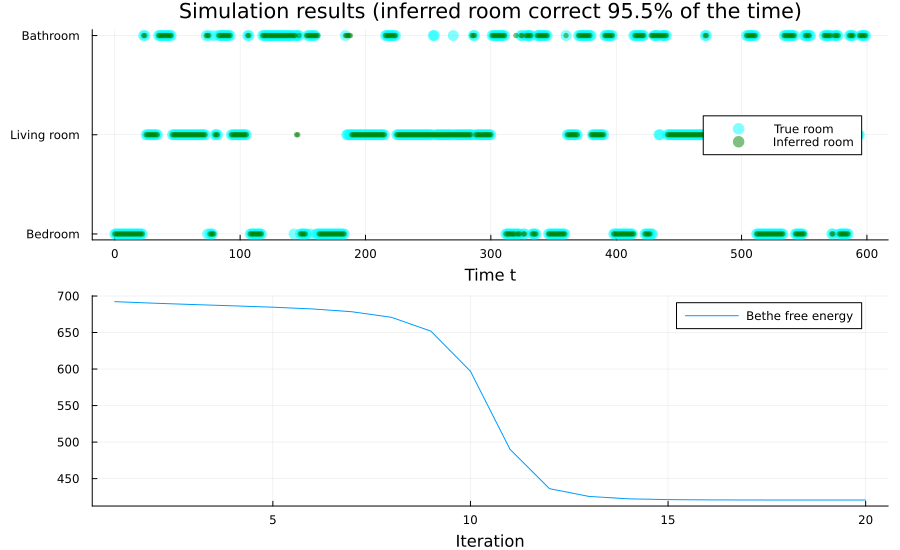

In [26]:
rooms          = [argmax(Lŝˣ[0]) for Lŝˣ in parent(Lŝˣː)]                ## true room of ŝ^{*[t,0]}, t = 0, ..., T
inferred_rooms = argmax.(ReactiveMP.probvec.(result.posteriors[:sː]))   ## most probable room under Q(s^{[t,0]})
accuracy       = mean(inferred_rooms .== rooms)

p1 = scatter(0:T, rooms,
    title="Simulation results (inferred room correct $(round(100*accuracy, digits=1))% of the time)",
    label="True room",
    legend=:right,
    xlabel="Time t",
    yticks=(1:3, ["Bedroom", "Living room", "Bathroom"]),
    markercolor=:cyan,
    markersize=6,
    markerstrokewidth=0,
    alpha=.5,
    size=(900,550)
)
scatter!(p1, 0:T, inferred_rooms,
    label="Inferred room",
    markercolor=:green,
    markersize=3,
    markerstrokewidth=0,
    alpha=.5
)
p2 = plot(result.free_energy,
    label="Bethe free energy",
    xlabel="Iteration"
)
plot(p1, p2, layout=@layout([ a; b ]))